In [2]:
#Imports 
import numpy as np
import pandas as pd
import scipy.stats as stats
import math

import matplotlib.pyplot as plt
%matplotlib inline

import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from wooldridge import dataWoo
import linearmodels as panel
import statsmodels.formula.api as smf
import statsmodels.base.model as smclass
import patsy as pt
from statsmodels.tsa.stattools import adfuller


In [3]:
dataWoo()

  J.M. Wooldridge (2019) Introductory Econometrics: A Modern Approach,
  Cengage Learning, 6th edition.

  401k       401ksubs    admnrev       affairs     airfare
  alcohol    apple       approval      athlet1     athlet2
  attend     audit       barium        beauty      benefits
  beveridge  big9salary  bwght         bwght2      campus
  card       catholic    cement        census2000  ceosal1
  ceosal2    charity     consump       corn        countymurders
  cps78_85   cps91       crime1        crime2      crime3
  crime4     discrim     driving       earns       econmath
  elem94_95  engin       expendshares  ezanders    ezunem
  fair       fertil1     fertil2       fertil3     fish
  fringe     gpa1        gpa2          gpa3        happiness
  hprice1    hprice2     hprice3       hseinv      htv
  infmrt     injury      intdef        intqrt      inven
  jtrain     jtrain2     jtrain3       kielmc      lawsch85
  loanapp    lowbrth     mathpnl       meap00_01   meap01
  meap93    

In [4]:
dataWoo('ceosal1', description=True)


name of dataset: ceosal1
no of variables: 12
no of observations: 209

+----------+-------------------------------+
| variable | label                         |
+----------+-------------------------------+
| salary   | 1990 salary, thousands $      |
| pcsalary | % change salary, 89-90        |
| sales    | 1990 firm sales, millions $   |
| roe      | return on equity, 88-90 avg   |
| pcroe    | % change roe, 88-90           |
| ros      | return on firm's stock, 88-90 |
| indus    | =1 if industrial firm         |
| finance  | =1 if financial firm          |
| consprod | =1 if consumer product firm   |
| utility  | =1 if transport. or utilties  |
| lsalary  | natural log of salary         |
| lsales   | natural log of sales          |
+----------+-------------------------------+

I took a random sample of data reported in the May 6, 1991 issue of
Businessweek.


In [5]:
df = dataWoo('ceosal1')

In [12]:
descriptive = df.describe()
descriptive

,salary,pcsalary,sales,roe,pcroe,ros,indus,finance,consprod,utility,lsalary,lsales
count,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000,209.000000
mean,1281.119617,13.282297,6923.793282,17.184211,10.800478,61.803828,0.320574,0.220096,0.287081,0.172249,6.950386,8.292265
std,1372.345308,32.633921,10633.271088,8.518509,97.219399,68.177052,0.467818,0.415306,0.453486,0.378503,0.566374,1.013161
min,223.000000,-61.000000,175.199997,0.500000,-98.900002,-58.000000,0.000000,0.000000,0.000000,0.000000,5.407172,5.165928
25%,736.000000,-1.000000,2210.300049,12.400000,-21.200001,21.000000,0.000000,0.000000,0.000000,0.000000,6.601230,7.700883
50%,1039.000000,9.000000,3705.199951,15.500000,-3.000000,52.000000,0.000000,0.000000,0.000000,0.000000,6.946014,8.217492
75%,1407.000000,20.000000,7177.000000,20.000000,19.500000,81.000000,1.000000,0.000000,1.000000,0.000000,7.249215,8.878636
max,14822.000000,212.000000,97649.898438,56.299999,977.000000,418.000000,1.000000,1.000000,1.000000,1.000000,9.603868,11.489144


In [22]:
descriptive = df[['salary', 'roe']].describe
print(descriptive)


<bound method NDFrame.describe of      salary   roe
0      1095  14.1
1      1001  10.9
2      1122  23.5
3       578   5.9
4      1368  13.8
..      ...   ...
204     930   9.0
205     525  15.5
206     658  12.1
207     555  13.7
208     626  14.4

[209 rows x 2 columns]>


In [23]:
model = smf.ols('salary ~ roe', data=df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                 salary   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.008
Method:                 Least Squares   F-statistic:                     2.767
Date:                Tue, 26 Aug 2025   Prob (F-statistic):             0.0978
Time:                        20:39:03   Log-Likelihood:                -1804.5
No. Observations:                 209   AIC:                             3613.
Df Residuals:                     207   BIC:                             3620.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    963.1913    213.240      4.517      0.0

Least Squares Regression Results: P-value shows, results are statistically significant. It shows that 1 point increase on Return of Equity increases CEO salaries approximately 18.5 thousand US Dollars. But, also it should considered that model could only explain little amount of the data which due to one variable analysis only - covering all data in the dataset (looking R-Squared and Adj. R-Squared scores). It only explains %1.3 of the variance which is really low. RoE seems have an effect on salary increase but slightly, not everytime, not in every situation. It could depend a lot of other variables which were given in the dataset.

Due to R-Squared results we can say RoE is not fully enough to explain what reasons a CEO's salary increase, but it is a significant variable for sure.

In [ ]:
prediction = model.get_prediction(exog=dict(roe=[0,30]))   # Predicting what if RoE is between 0 and 30?
prediction.summary_frame()

,mean,mean_se,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
0,963.191336,213.240257,542.790219,1383.592454,-1763.560715,3689.943388
1,1518.226927,171.045889,1181.011599,1855.442254,-1196.944122,4233.397976


When RoE is 0, the CEO's salary is expected to be around 963 Thousand US Dollars. In %95 confidence interval expected salary is between 542 Thousand US Dollars and 1.383 Million US Dollars
When RoE is 30, the the CEO's salary is expected to be around 1.5 Million US Dollars. In %95 confidence interval expected salary is between 1.1 Million US Dollars and 1.85 Million US Dollars
This clearly shows that, if RoE goes high, salary goes higher.

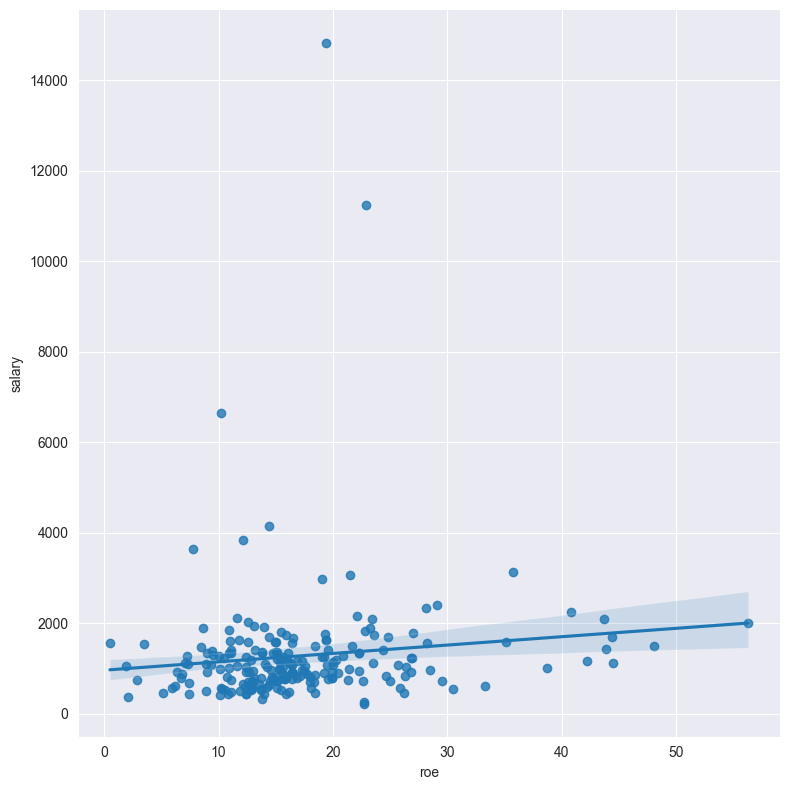

In [ ]:
# Graphing the regression results
sns.set_style('darkgrid')
sns.lmplot(x='roe', y='salary', data=df, height=8)